Memuat Library dan Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/Dataset Google Maps Review.csv')

In [7]:
# Melihat isi dataset 5 baris pertama
df.head()

,title,url,stars,name,reviewUrl,text
0,Taman Safari Indonesia Bogor,https://www.google.com/maps/search/?api=1&quer...,5,Ekha Bazz,https://www.google.com/maps/reviews/data=!4m8!...,NaN
1,Taman Safari Indonesia Bogor,https://www.google.com/maps/search/?api=1&quer...,5,Marvel Hans,https://www.google.com/maps/reviews/data=!4m8!...,seru bangettt main disinii
2,Taman Safari Indonesia Bogor,https://www.google.com/maps/search/?api=1&quer...,5,lee seo youl,https://www.google.com/maps/reviews/data=!4m8!...,NaN
3,Taman Safari Indonesia Bogor,https://www.google.com/maps/search/?api=1&quer...,5,Elva DevAr,https://www.google.com/maps/reviews/data=!4m8!...,"Little moments, big happiness ✨"
4,Taman Safari Indonesia Bogor,https://www.google.com/maps/search/?api=1&quer...,5,ido neria,https://www.google.com/maps/reviews/data=!4m8!...,NaN


In [8]:
# Cek nilai yang kosong
df.isnull().sum()

,0
title,0
url,0
stars,0
name,0
reviewUrl,0
text,4547


In [9]:
# Cek data duplikat
df.duplicated().sum()

np.int64(1480)

Menghapus Nilai Kosong (Null/NaN)

In [10]:
# Menghapus baris yang memiliki nilai null pada kolom 'text'
df_clean = df.dropna(subset=['text'])

print("Dimensi data setelah hapus null:", df_clean.shape)

Dimensi data setelah hapus null: (11453, 6)


Menghapus Data Duplikat

In [11]:
# Menghapus baris duplikat
df_clean = df_clean.drop_duplicates()

print("Dimensi data setelah hapus duplikat:", df_clean.shape)

Dimensi data setelah hapus duplikat: (9973, 6)


Konversi Rating (Stars) Menjadi Label Sentimen

In [12]:
# Fungsi untuk menentukan label berdasarkan bintang
def konversi_label(star):
    if star >= 4:
        return 'Positif'
    elif star == 3:
        return 'Netral'
    else:
        return 'Negatif'

# Mengaplikasikan fungsi ke kolom 'stars' dan membuat kolom baru 'label'
# Menggunakan .copy() sebelumnya untuk menghindari peringatan SettingWithCopyWarning dari pandas
df_clean = df_clean.copy()
df_clean['label'] = df_clean['stars'].apply(konversi_label)

# Melihat distribusi label yang baru dibuat
print("\nDistribusi Label:")
print(df_clean['label'].value_counts())

# Menampilkan data hasil
df_clean[['stars', 'text', 'label']].head()


Distribusi Label:
label
Positif    9324
Negatif     334
Netral      315
Name: count, dtype: int64


,stars,text,label
1,5,seru bangettt main disinii,Positif
3,5,"Little moments, big happiness ✨",Positif
5,3,Rasanya sekarang kayak kurang worth it .\n- He...,Netral
10,5,Pengalaman Luar biasa,Positif
12,4,مكان جميل ويستحق الزيارة للكبار والصغار ولكن ا...,Positif


Mengecek ulang data dan Menyimpan Hasil

In [13]:
df_clean.isnull().sum()

,0
title,0
url,0
stars,0
name,0
reviewUrl,0
text,0
label,0


In [14]:
# Menyimpan dataframe ke CSV baru
df_clean.to_csv("Dataset_Cleaned_Labeled.csv", index=False)
print("Data berhasil disimpan!")

Data berhasil disimpan!


In [15]:
df = pd.read_csv('/content/Dataset_Cleaned_Labeled.csv')

# instalasi sastrawi

In [16]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.4 MB/s eta 0:00:00


In [17]:
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('punkt')
nltk.download('punkt_tab')

# Inisialisasi objek Sastrawi di luar fungsi agar performa lebih cepat
stop_factory = StopWordRemoverFactory()
stopword_remover = stop_factory.create_stop_word_remover()

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# **Preprocessing**

In [18]:
import re
import string
from nltk.tokenize import word_tokenize

def case_folding(text):
    text = text.lower()
    # Hapus URL, mention, dan hashtag
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)
    # PERBAIKAN: Ganti ASCII ignore dengan filter karakter huruf saja
    # Ini agar emoji hilang tapi kata-kata tidak terpotong kasar
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Gunakan pipeline yang sudah diperbaiki
df_clean['case_folding'] = df_clean['text'].apply(case_folding)
df_clean['tokenized'] = df_clean['case_folding'].apply(word_tokenize)

In [19]:
import nltk
from nltk.tokenize import word_tokenize

#B. Tokenization
def tokenization(text):
    return word_tokenize(text)

# Apply case_folding before tokenization
df_clean['case_folding'] = df_clean['text'].apply(case_folding)

# Menampilkan hasil Tokenization (5 baris)
df_clean['tokenized'] = df_clean['case_folding'].apply(tokenization)
df_clean[['case_folding', 'tokenized']].head()

,case_folding,tokenized
1,seru bangettt main disinii,"[seru, bangettt, main, disinii]"
3,little moments big happiness,"[little, moments, big, happiness]"
5,rasanya sekarang kayak kurang worth it hewan d...,"[rasanya, sekarang, kayak, kurang, worth, it, ..."
10,pengalaman luar biasa,"[pengalaman, luar, biasa]"
12,,[]


In [20]:
#C. Stopword Removal
def remove_stopwords(tokens):
    sentence = " ".join(tokens)
    out_sentence = stopword_remover.remove(sentence)
    return out_sentence.split()

# Menampilkan hasil Stopword Removal (5 baris)
df_clean['stopword_removal'] = df_clean['tokenized'].apply(remove_stopwords)
df_clean[['tokenized', 'stopword_removal']].head()

,tokenized,stopword_removal
1,"[seru, bangettt, main, disinii]","[seru, bangettt, main, disinii]"
3,"[little, moments, big, happiness]","[little, moments, big, happiness]"
5,"[rasanya, sekarang, kayak, kurang, worth, it, ...","[rasanya, sekarang, kayak, kurang, worth, it, ..."
10,"[pengalaman, luar, biasa]","[pengalaman, luar, biasa]"
12,[],[]


In [36]:
#D. Stemming
def stemming(tokens):
    sentence = " ".join(tokens)
    stemmed_sentence = stemmer.stem(sentence)
    return stemmed_sentence

# Menampilkan hasil Stemming (5 baris)
# Ingat: Bagian ini akan memakan waktu paling lama
print("Sedang memproses Stemming...")
df_clean['stemmed'] = df_clean['stopword_removal'].apply(stemming)
df_clean[['stopword_removal', 'stemmed']].head()

Sedang memproses Stemming...


,stopword_removal,stemmed
1,"[seru, bangettt, main, disinii]",seru bangettt main sini
3,"[little, moments, big, happiness]",little moments big happiness
5,"[rasanya, sekarang, kayak, kurang, worth, it, ...",rasa sekarang kayak kurang worth it hewan area...
10,"[pengalaman, luar, biasa]",alam luar biasa
12,[],


# **Feature Extraction**

**1. Persiapan & Load Data**

In [22]:
!pip install gensim
import pandas as pd
import numpy as np
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# Asumsi df adalah dataframe dari bagian sebelumnya
# Pastikan kolom text_clean adalah kolom yang sudah di-preprocess (stemming)
data_clean = df_clean['stemmed'].astype(str)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 12.4 MB/s eta 0:00:00


**2. Implementasi TF-IDF (Representasi 1)**

In [23]:
# Inisialisasi TF-IDF Vectorizer
tfidf_vect = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)

# Fit dan Transform data
X_tfidf = tfidf_vect.fit_transform(data_clean)

print(f"Dimensi TF-IDF: {X_tfidf.shape}")

# Simpan vectorizer untuk deployment (Gradio) nanti
pickle.dump(tfidf_vect, open("tfidf_vectorizer.pkl", "wb"))

Dimensi TF-IDF: (9973, 10000)


**3. Implementasi Word Embedding - Word2Vec (Representasi 2)**

In [24]:
# Tokenisasi ulang untuk Word2Vec (butuh list of lists)
sentences = [sentence.split() for sentence in data_clean]

# Training model Word2Vec
# vector_size=100 artinya setiap kata diubah jadi 100 angka
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# Fungsi untuk mengubah satu ulasan menjadi satu vektor (Averaging)
def get_average_word2vec(tokens, model, vector_size):
    vec = np.zeros(vector_size)
    count = 0
    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    if count != 0:
        vec /= count
    return vec

# Transformasi seluruh dataset menjadi vektor Word2Vec
X_w2v = np.array([get_average_word2vec(s, w2v_model, 100) for s in sentences])

print(f"Dimensi Word2Vec: {X_w2v.shape}")

# Simpan model Word2Vec untuk deployment
w2v_model.save("w2v_model.bin")

Dimensi Word2Vec: (9973, 100)


**4. Perbandingan Hasil Vector**

In [ ]:
# Contoh melihat 5 fitur pertama dari TF-IDF
print("Contoh Fitur TF-IDF:", tfidf_vect.get_feature_names_out()[:5])

# Contoh melihat vektor kata 'satwa' di Word2Vec
if 'satwa' in w2v_model.wv:
    print("Vektor kata 'satwa' (10 dimensi pertama):", w2v_model.wv['satwa'][:10])

# **Modeling**

**1. Naive Bayes**

In [26]:
from  sklearn.model_selection  import  train_test_split
from  sklearn.metrics  import  accuracy_score ,  classification_report
from  sklearn.naive_bayes import ComplementNB

# Menyiapkan data untuk TF-IDF
X = X_tfidf  # Fitur TF-IDF yang sudah dihitung
y = df_clean [ 'label' ] # Labels dari df_clean

# Pisahkan data pelatihan dan data pengujian
X_train_tfidf ,  X_test_tfidf ,  y_train ,  y_test = train_test_split ( X ,  y ,  test_size= 0.2 ,  random_state= 42 )

# Melatih model Naive Bayes dengan TF-IDF
nb_tfidf = ComplementNB()
nb_tfidf.fit ( X_train_tfidf ,  y_train )

# Membuat prediksi dan evaluasi
y_pred_nb_tfidf = nb_tfidf.predict( X_test_tfidf )

print ( "Naive Bayes (TF-IDF)" )
print ( "Akurasi:" ,  accuracy_score ( y_test ,  y_pred_nb_tfidf))
print("Complement Naive Bayes:\n", classification_report(y_test, y_pred_nb_tfidf))

Naive Bayes (TF-IDF)
Akurasi: 0.8962406015037594
Complement Naive Bayes:
               precision    recall  f1-score   support

     Negatif       0.19      0.24      0.21        75
      Netral       0.04      0.02      0.02        61
     Positif       0.94      0.95      0.95      1859

    accuracy                           0.90      1995
   macro avg       0.39      0.40      0.39      1995
weighted avg       0.89      0.90      0.89      1995



**2. Logistic Regression**

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Menyiapkan data untuk TF-IDF
X = X_tfidf # Fitur TF-IDF yang sudah dihitung
y = df_clean['label'] # Label dari df_clean

# Split data training dan data testing
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melatih model Regresi Logistik dengan TF-IDF
class_wieght = 'balanced'
lr_tfidf = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=42) # max_iter ditingkatkan untuk konvergensi
lr_tfidf.fit(X_train_tfidf, y_train)

# Membuat prediksi dan evaluasi
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("Regresi Logistik (TF-IDF)")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_tfidf))
print("Logistic Regression (Balanced): \n", classification_report(y_test, y_pred_lr_tfidf))

Regresi Logistik (TF-IDF)
Accuracy: 0.9323308270676691
Logistic Regression (Balanced): 
               precision    recall  f1-score   support

     Negatif       0.52      0.21      0.30        75
      Netral       0.24      0.07      0.10        61
     Positif       0.95      0.99      0.97      1859

    accuracy                           0.93      1995
   macro avg       0.57      0.42      0.46      1995
weighted avg       0.91      0.93      0.92      1995



**3. SVM**

In [28]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Menyiapkan data untuk TF-IDF
X = X_tfidf # Fitur TF-IDF yang sudah dihitung
y = df_clean['label'] # Label dari df_clean

# Split data training dan data testing
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melatih model SVM (LinearSVC) dengan TF-IDF
# LinearSVC biasanya lebih cepat untuk dataset besar dan data sparse seperti TF-IDF
class_weight='balanced'
svm_tfidf = LinearSVC(max_iter=10000, class_weight='balanced', random_state=42) # Meningkatkan max_iter untuk konvergensi
svm_tfidf.fit(X_train_tfidf, y_train)

# Membuat prediksi dan evaluasi
y_pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)

print("Support Vector Machine (TF-IDF)")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_tfidf))
print("SVM((Balanced):\n", classification_report(y_test, y_pred_svm_tfidf))

Support Vector Machine (TF-IDF)
Accuracy: 0.9298245614035088
SVM((Balanced):
               precision    recall  f1-score   support

     Negatif       0.41      0.24      0.30        75
      Netral       0.38      0.18      0.24        61
     Positif       0.95      0.98      0.97      1859

    accuracy                           0.93      1995
   macro avg       0.58      0.47      0.50      1995
weighted avg       0.91      0.93      0.92      1995



# **Comparison Model**

**1. TF-IDF vs Embedding**

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

y = df_clean['label'] # Label target

print("=== Perbandingan TF-IDF vs Word2Vec (Menggunakan Logistic Regression) ===\n")

# --- TF-IDF ---
print("## TF-IDF Features ##")
# Split data training dan testing untuk TF-IDF
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Melatih model Logistic Regression dengan TF-IDF
lr_tfidf_comp = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
lr_tfidf_comp.fit(X_train_tfidf, y_train_tfidf)

# Membuat prediksi dan evaluasi
y_pred_lr_tfidf_comp = lr_tfidf_comp.predict(X_test_tfidf)

print("Akurasi (TF-IDF):", accuracy_score(y_test_tfidf, y_pred_lr_tfidf_comp))
print("Laporan Klasifikasi (TF-IDF):\n", classification_report(y_test_tfidf, y_pred_lr_tfidf_comp, zero_division=0))

# --- Word2Vec ---
print("\n## Word2Vec Features ##")
# Split data training dan testing untuk Word2Vec
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

# Melatih model Logistic Regression dengan Word2Vec
# Untuk Word2Vec, gunakan solver yang cocok untuk data dense (misalnya 'lbfgs' atau 'sag')
lr_w2v_comp = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_w2v_comp.fit(X_train_w2v, y_train_w2v)

# Membuat prediksi dan evaluasi
y_pred_lr_w2v_comp = lr_w2v_comp.predict(X_test_w2v)

print("Akurasi (Word2Vec):", accuracy_score(y_test_w2v, y_pred_lr_w2v_comp))
print("Laporan Klasifikasi (Word2Vec):\n", classification_report(y_test_w2v, y_pred_lr_w2v_comp, zero_division=0))


=== Perbandingan TF-IDF vs Word2Vec (Menggunakan Logistic Regression) ===

## TF-IDF Features ##
Akurasi (TF-IDF): 0.9323308270676691
Laporan Klasifikasi (TF-IDF):
               precision    recall  f1-score   support

     Negatif       1.00      0.01      0.03        75
      Netral       0.00      0.00      0.00        61
     Positif       0.93      1.00      0.96      1859

    accuracy                           0.93      1995
   macro avg       0.64      0.34      0.33      1995
weighted avg       0.91      0.93      0.90      1995


## Word2Vec Features ##
Akurasi (Word2Vec): 0.931328320802005
Laporan Klasifikasi (Word2Vec):
               precision    recall  f1-score   support

     Negatif       0.33      0.01      0.03        75
      Netral       0.00      0.00      0.00        61
     Positif       0.93      1.00      0.96      1859

    accuracy                           0.93      1995
   macro avg       0.42      0.34      0.33      1995
weighted avg       0.88      0.9

**2. Model A vs Model B**

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Mempersiapkan data (menggunakan fitur TF-IDF yang sudah ada)
X = X_tfidf
y = df_clean['label']

# Membagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== Perbandingan Model: Logistic Regression (Model A) vs SVM (Model B) ===\n")

# --- Model A: Logistic Regression ---
print("## Model A: Logistic Regression (TF-IDF) ##")
lr_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Akurasi (Logistic Regression):", accuracy_score(y_test, y_pred_lr))
print("Laporan Klasifikasi (Logistic Regression):\n", classification_report(y_test, y_pred_lr, zero_division=0))

# --- Model B: Support Vector Machine (LinearSVC) ---
print("\n## Model B: Support Vector Machine (TF-IDF) ##")
svm_model = LinearSVC(max_iter=10000, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Akurasi (SVM):", accuracy_score(y_test, y_pred_svm))
print("Laporan Klasifikasi (SVM):\n", classification_report(y_test, y_pred_svm, zero_division=0))


=== Perbandingan Model: Logistic Regression (Model A) vs SVM (Model B) ===

## Model A: Logistic Regression (TF-IDF) ##
Akurasi (Logistic Regression): 0.9323308270676691
Laporan Klasifikasi (Logistic Regression):
               precision    recall  f1-score   support

     Negatif       1.00      0.01      0.03        75
      Netral       0.00      0.00      0.00        61
     Positif       0.93      1.00      0.96      1859

    accuracy                           0.93      1995
   macro avg       0.64      0.34      0.33      1995
weighted avg       0.91      0.93      0.90      1995


## Model B: Support Vector Machine (TF-IDF) ##
Akurasi (SVM): 0.9363408521303258
Laporan Klasifikasi (SVM):
               precision    recall  f1-score   support

     Negatif       0.62      0.20      0.30        75
      Netral       0.50      0.05      0.09        61
     Positif       0.94      1.00      0.97      1859

    accuracy                           0.94      1995
   macro avg       0.69

# **Metric**

**1. Accuracy**

In [31]:
from sklearn.metrics import accuracy_score

# Menggunakan hasil prediksi dari Logistic Regression (TF-IDF)
# Variabel y_test_tfidf dan y_pred_lr_tfidf_comp yang udah ada dari langkah sebelumnya

accuracy = accuracy_score(y_test_tfidf, y_pred_lr_tfidf_comp)
print(f"Akurasi Model Regresi Logistik (TF-IDF): {accuracy:.4f}")

Akurasi Model Regresi Logistik (TF-IDF): 0.9323


**2. Precision**

In [32]:
from sklearn.metrics import precision_score

# Menghitung presisi per kelas
precision_per_class = precision_score(y_test_tfidf, y_pred_lr_tfidf_comp, average=None, labels=['Negatif', 'Netral', 'Positif'], zero_division=0)

# Menghitung presisi rata-rata tertimbang
precision_weighted = precision_score(y_test_tfidf, y_pred_lr_tfidf_comp, average='weighted', zero_division=0)

print("Presisi per Kelas:")
print(f"  Negatif: {precision_per_class[0]:.4f}")
print(f"  Netral:  {precision_per_class[1]:.4f}")
print(f"  Positif: {precision_per_class[2]:.4f}")
print(f"\nPresisi Rata-rata Tertimbang: {precision_weighted:.4f}")

Presisi per Kelas:
  Negatif: 1.0000
  Netral:  0.0000
  Positif: 0.9323

Presisi Rata-rata Tertimbang: 0.9063


**3. Recall**

In [33]:
from sklearn.metrics import recall_score

# Menghitung recall per kelas
recall_per_class = recall_score(y_test_tfidf, y_pred_lr_tfidf_comp, average=None, labels=['Negatif', 'Netral', 'Positif'], zero_division=0)

# Menghitung recall rata-rata tertimbang
recall_weighted = recall_score(y_test_tfidf, y_pred_lr_tfidf_comp, average='weighted', zero_division=0)

print("Recall per Kelas:")
print(f"  Negatif: {recall_per_class[0]:.4f}")
print(f"  Netral:  {recall_per_class[1]:.4f}")
print(f"  Positif: {recall_per_class[2]:.4f}")
print(f"\nRecall Rata-rata Tertimbang: {recall_weighted:.4f}")

Recall per Kelas:
  Negatif: 0.0133
  Netral:  0.0000
  Positif: 1.0000

Recall Rata-rata Tertimbang: 0.9323


**4. F1-score**

In [40]:
from sklearn.metrics import f1_score

# Menghitung F1-score per kelas
f1_per_class = f1_score(y_test_tfidf, y_pred_lr_tfidf_comp, average=None, labels=['Negatif', 'Netral', 'Positif'], zero_division=0)

# Menghitung F1-score rata-rata tertimbang
f1_weighted = f1_score(y_test_tfidf, y_pred_lr_tfidf_comp, average='weighted', zero_division=0)

print("F1-score per Kelas:")
print(f"  Negatif: {f1_per_class[0]:.4f}")
print(f"  Netral:  {f1_per_class[1]:.4f}")
print(f"  Positif: {f1_per_class[2]:.4f}")
print(f"\nF1-score Rata-rata Tertimbang: {f1_weighted:.4f}")

F1-score per Kelas:
  Negatif: 0.0263
  Netral:  0.0000
  Positif: 0.9650

F1-score Rata-rata Tertimbang: 0.9002


# Visualisasi

Visualisasi Distribusi Label (Pie Chart & Bar Chart)

/tmp/ipykernel_5635/3303966988.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_clean, palette='viridis')


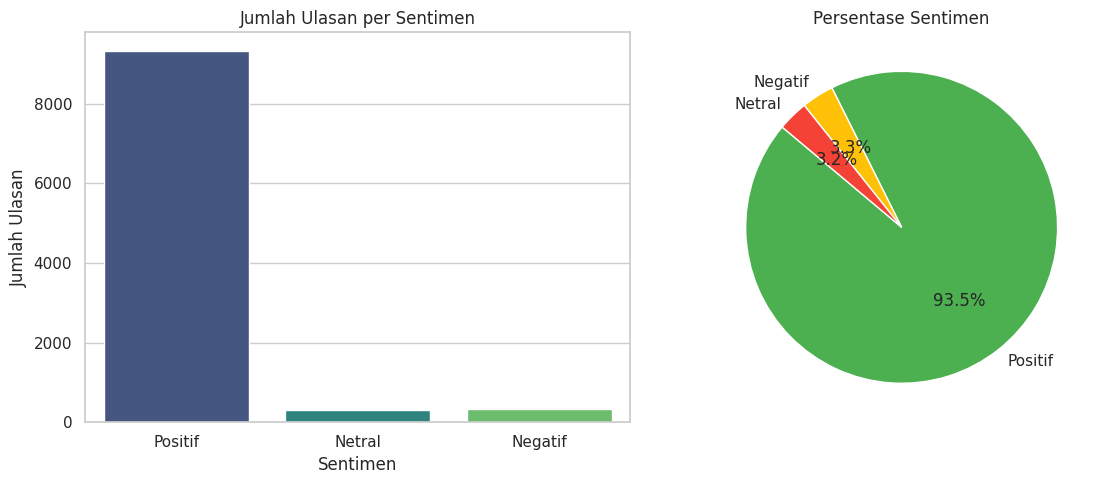

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Bar Chart
plt.subplot(1, 2, 1)
sns.countplot(x='label', data=df_clean, palette='viridis')
plt.title('Jumlah Ulasan per Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')

# 2. Pie Chart
plt.subplot(1, 2, 2)
df_clean['label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4CAF50', '#FFC107', '#F44336'], startangle=140)
plt.title('Persentase Sentimen')
plt.ylabel('')

plt.tight_layout()
plt.show()

Visualisasi Kata Terbanyak (WordCloud)

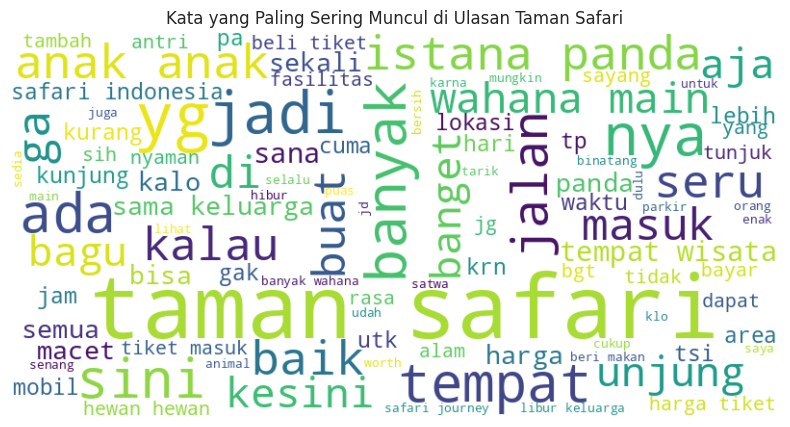

In [46]:
from wordcloud import WordCloud

# Gabungkan semua ulasan yang sudah di-stemming menjadi satu string besar
all_words = ' '.join([text for text in df_clean['stemmed']])

# Buat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(all_words)

# Tampilkan
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Kata yang Paling Sering Muncul di Ulasan Taman Safari')
plt.show()

#Gradio

In [ ]:
import gradio as gr

def predict_sentiment(teks_input):
    # 1. Pipeline Preprocessing Lengkap (Harus sama dengan training)
    # A. Case Folding
    clean_text = case_folding(teks_input)

    # B. Tokenizing
    tokens = word_tokenize(clean_text)

    # C. Stopword Removal
    tokens_no_stop = remove_stopwords(tokens)

    # D. Stemming (Penting: Model kamu dilatih pakai kata dasar!)
    final_text = stemming(tokens_no_stop)

    # 2. Transformasi ke TF-IDF
    # Pastikan tfidf_vect sudah menggunakan ngram_range=(1,2) dari cell sebelumnya
    teks_vektor = tfidf_vect.transform([final_text])

    # 3. Prediksi menggunakan Model yang sudah di-Balanced
    # Kita gunakan svm_tfidf (Hasil perbaikan dari cell Lestari)
    prediksi = svm_tfidf.predict(teks_vektor)[0]

    # (Opsional) Mengambil skor probabilitas agar tampilan Gradio lebih keren
    # Jika menggunakan LinearSVC, kita gunakan decision_function
    return prediksi

# --- KONFIGURASI UI GRADIO ---
# Menggunakan tema yang lebih modern (Industrial/Clean) sesuai selera kamu
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("ZooSense: Analisis Sentimen Taman Safari")
    gr.Markdown("Aplikasi untuk mendeteksi emosi pengunjung berdasarkan ulasan Google Maps.")

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                label="Tulis Ulasan Anda",
                placeholder="Contoh: Antreannya panjang sekali dan sangat macet...",
                lines=5
            )
            btn = gr.Button("Analisis Sentimen", variant="primary")

        with gr.Column():
            output_label = gr.Label(label="Prediksi Kategori")

    # Logika Klik Tombol
    btn.click(fn=predict_sentiment, inputs=input_text, outputs=output_label)

    gr.Examples(
        examples=[
            ["Tempatnya seru, hewannya banyak!"],
            ["Harganya terlalu mahal dan macet parah di jalan."],
            ["Taman Safari buka setiap hari dari jam 9 pagi."]
        ],
        inputs=input_text
    )

# Jalankan aplikasi dengan mode share untuk dikirim ke dosen
demo.launch(share=True, debug=True)

/tmp/ipykernel_5635/1999277507.py:31: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7a2af3978f6fbffef3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
